# Exploratory Data Analysis (EDA)

This notebook focuses on exploring the processed customer churn dataset, identifying patterns related to churn, and extracting useful business insights for further modelling.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\RATHICK A\OneDrive\Desktop\data analytics\data\telco_customer_churn_processed_for_modelling_with_target_leakage.csv")

In [37]:
df.head()

,Count,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Contract_Month-to-month,Contract_One year,Contract_Two year,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Group,Total Services,Support Services
0,1,90003,33.964131,-118.272783,1,0,0,0,2,1,...,1,0,0,0,0,0,1,New,3,2
1,1,90005,34.059281,-118.307420,0,0,0,1,2,1,...,1,0,0,0,0,1,0,New,1,0
2,1,90006,34.048013,-118.293953,0,0,0,1,8,1,...,1,0,0,0,0,1,0,New,5,1
3,1,90010,34.062125,-118.315709,0,0,1,1,28,1,...,1,0,0,0,0,1,0,Medium,6,2
4,1,90015,34.039224,-118.266293,1,0,0,1,49,1,...,1,0,0,1,0,0,0,Long-term,6,2


In [38]:
df.isnull().sum().sum()  #basic check 

np.int64(0)

In [39]:
df["Churn Label"].value_counts()

Churn Label
0    5174
1    1869
Name: count, dtype: int64

In [40]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
0    73.463013
1    26.536987
Name: proportion, dtype: float64

### Churn Distribution

This shows the overall distribution of customers who churned and those who stayed. We use this to understand the target variable and check whether there is any class imbalance before further analysis and modelling.

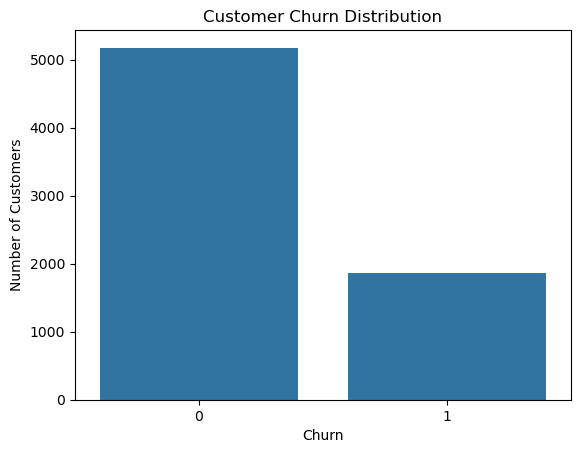

In [13]:
sns.countplot(data=df, x="Churn Label")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [25]:
df.columns.tolist()

['Count',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Paperless Billing',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Multiple Lines_No',
 'Multiple Lines_No phone service',
 'Multiple Lines_Yes',
 'Internet Service_DSL',
 'Internet Service_Fiber optic',
 'Internet Service_No',
 'Online Security_No',
 'Online Security_No internet service',
 'Online Security_Yes',
 'Online Backup_No',
 'Online Backup_No internet service',
 'Online Backup_Yes',
 'Device Protection_No',
 'Device Protection_No internet service',
 'Device Protection_Yes',
 'Tech Support_No',
 'Tech Support_No internet service',
 'Tech Support_Yes',
 'Streaming TV_No',
 'Streaming TV_No internet service',
 'Streaming TV_Yes',
 'Streaming Movies_No',
 'Streaming Movies_No internet service',
 'Streaming Movies_Yes',
 'Contract_Month-to-month',
 'Contract_One year',
 'Contract_Two year'

In [26]:
eda_df = pd.read_csv(r"C:\Users\RATHICK A\OneDrive\Desktop\data analytics\data\telco_customer_churn_processed.csv")

In [27]:
pd.crosstab(
    eda_df["Contract"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Contract Type vs Churn

This analysis compares churn across different contract types. We use it to identify whether customers with different contract durations show different churn patterns and to find contract groups that may need more attention.

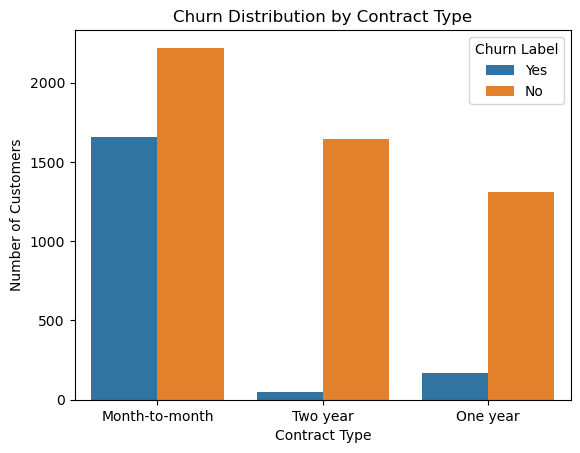

In [28]:
sns.countplot(data=eda_df, x="Contract", hue="Churn Label")

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

In [29]:
pd.crosstab(
    eda_df["Internet Service"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Internet Service vs Churn

This analysis compares churn across different internet service types. We use it to identify differences in churn behaviour between customers using DSL, Fiber optic, or no internet service.

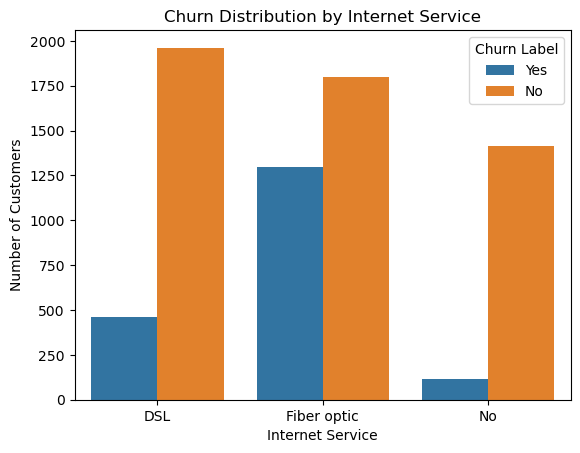

In [30]:
sns.countplot(
    data=eda_df,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Churn Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

In [33]:
pd.crosstab(
    eda_df["Tenure Months"],
    eda_df["Churn Label"],
    normalize="index"
).mul(100).head(20)

Churn Label,No,Yes
Tenure Months,,
0,100.000000,0.000000
1,38.009788,61.990212
2,48.319328,51.680672
3,53.000000,47.000000
4,52.840909,47.159091
5,51.879699,48.120301
6,63.636364,36.363636
7,61.068702,38.931298
8,65.853659,34.146341


In [31]:
eda_df.groupby("Churn Label")["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

### Tenure vs Churn

This analysis compares the tenure of churned and non-churned customers. We use it to understand whether customer loyalty or length of time with the company is related to churn behaviour.

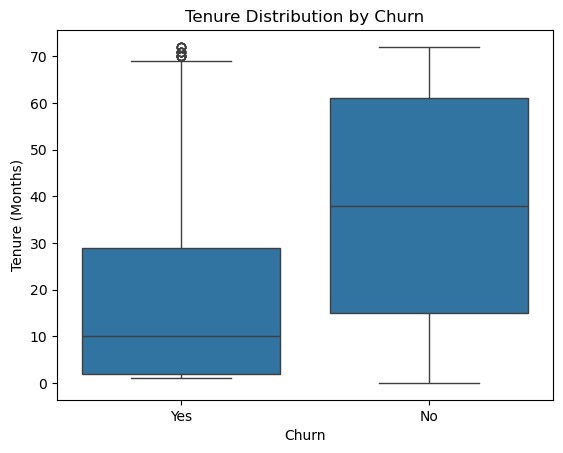

In [32]:
sns.boxplot(
    data=eda_df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [34]:
eda_df.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

### Monthly Charges vs Churn

This analysis compares the monthly charges of churned and non-churned customers. We use it to check whether customers with different monthly charges show different churn patterns.

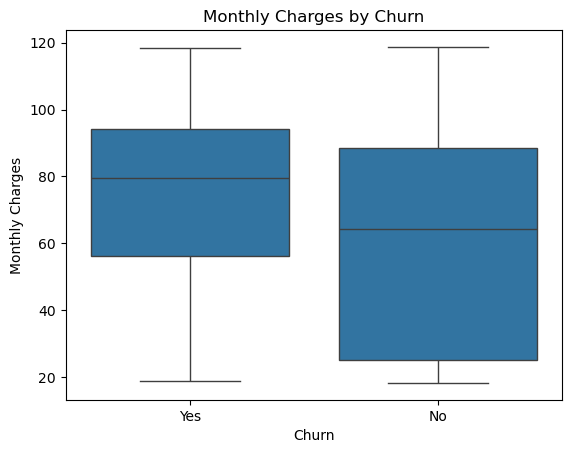

In [35]:
sns.boxplot(
    data=eda_df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [41]:
pd.crosstab(
    eda_df["Payment Method"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Payment Method vs Churn

This analysis compares churn across different payment methods. We use it to identify whether customers using different payment methods show different churn patterns and to find any payment groups with noticeably higher churn.

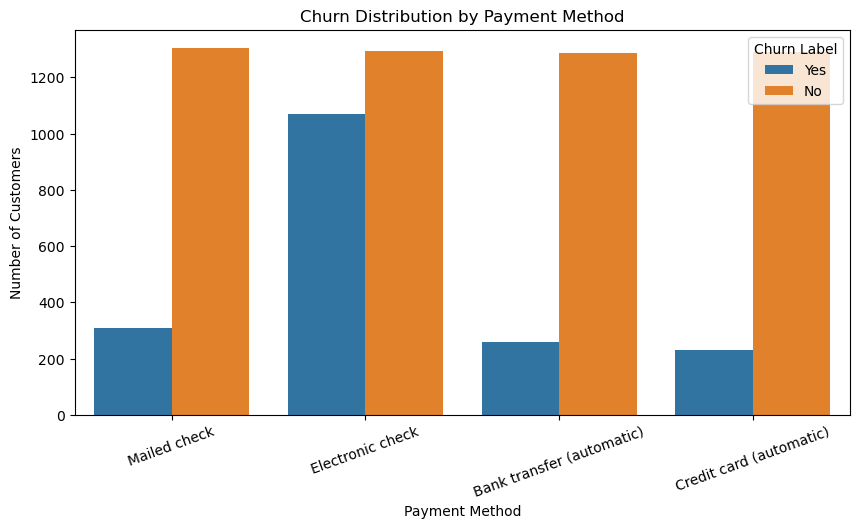

In [42]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=eda_df,
    x="Payment Method",
    hue="Churn Label"
)

plt.title("Churn Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [43]:
pd.crosstab(
    eda_df["Tech Support"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


### Tech Support vs Churn

This analysis compares churn across customers with different levels of tech support. We use it to check whether having tech support is associated with different churn patterns and customer retention.

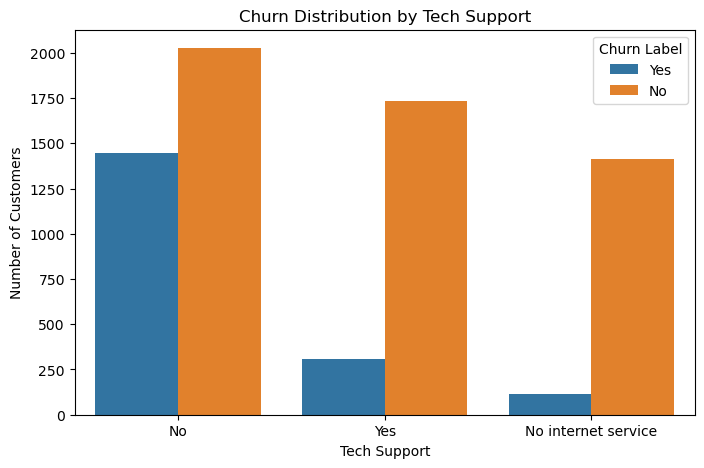

In [44]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=eda_df,
    x="Tech Support",
    hue="Churn Label"
)

plt.title("Churn Distribution by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.show()

In [45]:
pd.crosstab(
    eda_df["Online Security"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Online Security,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


### Online Security vs Churn

This analysis compares churn across customers with different online security services. We use it to check whether online security usage is associated with different churn patterns and customer retention.

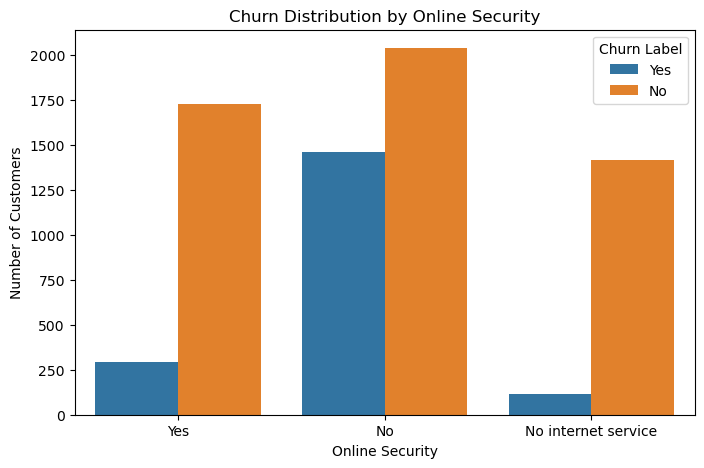

In [47]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=eda_df,
    x="Online Security",
    hue="Churn Label"
)

plt.title("Churn Distribution by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.show()

In [51]:
pd.crosstab(
    df["Total Services"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,0,1
Total Services,,
0,56.250000,43.750000
1,78.894768,21.105232
2,67.171717,32.828283
3,63.523316,36.476684
4,68.655098,31.344902
5,74.449339,25.550661
6,77.514793,22.485207
7,87.594937,12.405063
8,94.711538,5.288462


### Total Services vs Churn

This analysis examines the relationship between the total number of services used by a customer and churn. We use the feature created during feature engineering to check whether customers using different numbers of services show different churn patterns.

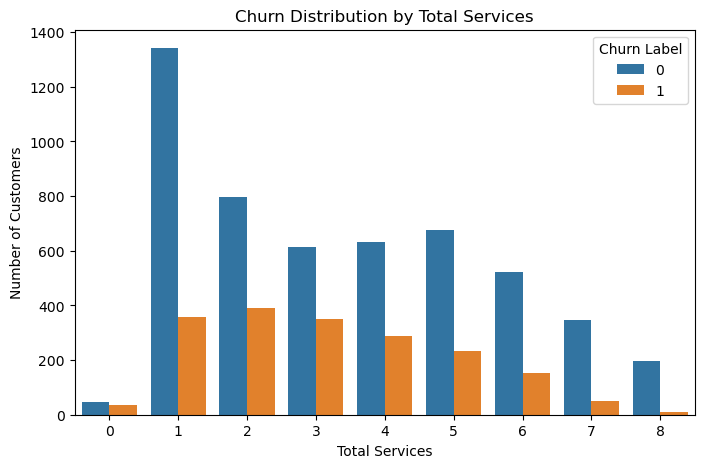

In [53]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Total Services",
    hue="Churn Label"
)

plt.title("Churn Distribution by Total Services")
plt.xlabel("Total Services")
plt.ylabel("Number of Customers")
plt.show()

In [54]:
pd.crosstab(
    df["Support Services"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,0,1
Support Services,,
0,70.247046,29.752954
1,61.145194,38.854806
2,76.239067,23.760933
3,87.566419,12.433581
4,94.680851,5.319149


### Support Services vs Churn

This analysis examines the relationship between the number of support services used by customers and churn. We use this feature to check whether customers with different levels of support show different churn patterns.

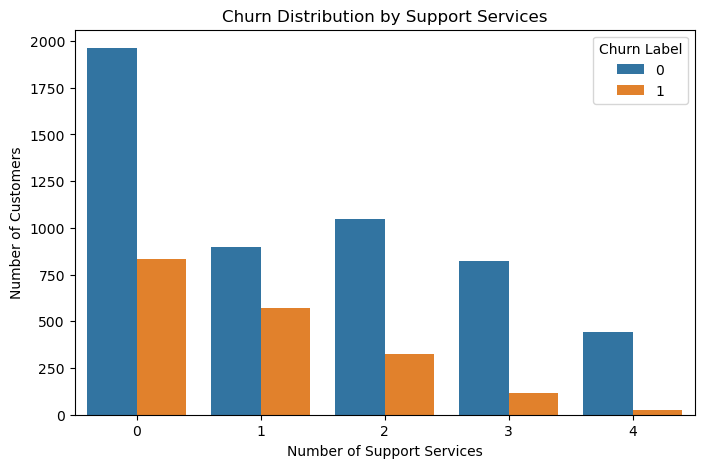

In [56]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Support Services",
    hue="Churn Label"
)

plt.title("Churn Distribution by Support Services")
plt.xlabel("Number of Support Services")
plt.ylabel("Number of Customers")
plt.show()

### Correlation Analysis

The correlation heatmap is used to examine relationships between numerical features and identify features that are strongly or weakly related to each other and to churn. This can help identify useful variables for modelling and detect highly correlated features.

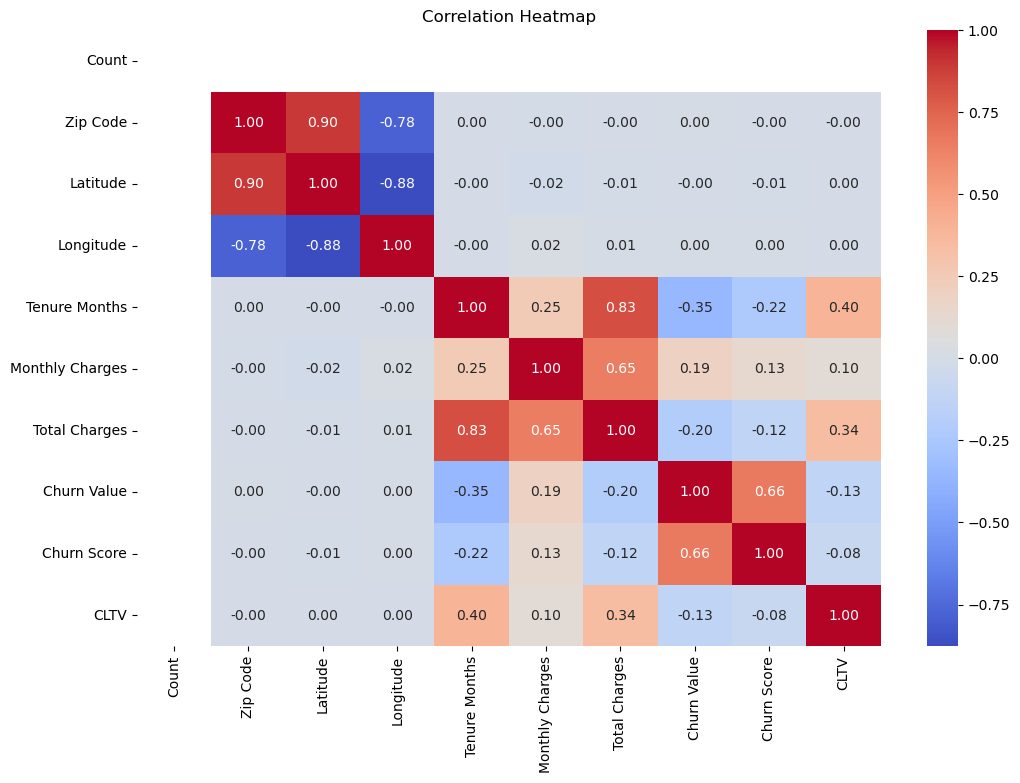

In [58]:
plt.figure(figsize=(12, 8))

corr = eda_df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap – Insights

The correlation heatmap shows the strength and direction of the linear relationship between numerical variables. Values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate a weak linear relationship.

From the heatmap, we can identify which numerical features are strongly related to each other and which features have a noticeable relationship with churn. This helps us understand patterns in the dataset and identify potentially useful features for modelling. However, correlation shows association and does not mean that one variable causes another.

In [59]:
eda_df.groupby("Churn Label")["Total Charges"].mean()

Churn Label
No     2549.911442
Yes    1531.796094
Name: Total Charges, dtype: float64

### Total Charges vs Churn

This analysis compares the total charges paid by churned and non-churned customers. It helps us understand whether the overall customer spending differs between the two groups and whether spending patterns are associated with churn.

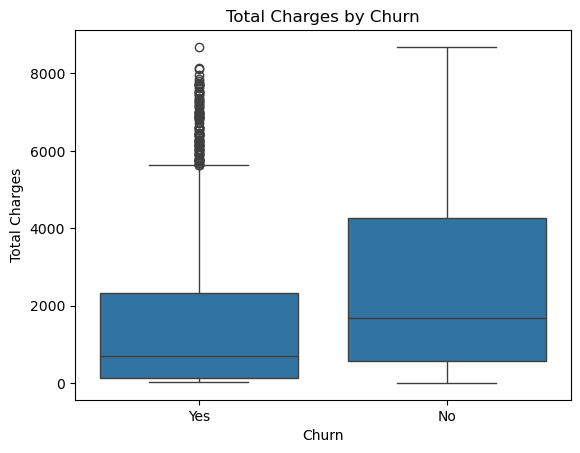

In [60]:
sns.boxplot(
    data=eda_df,
    x="Churn Label",
    y="Total Charges"
)

plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

In [61]:
pd.crosstab(
    eda_df["Senior Citizen"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


### Senior Citizen vs Churn

This analysis compares churn between senior and non-senior customers. We use it to check whether age-related customer groups show different churn patterns and whether senior citizen status is associated with customer retention.

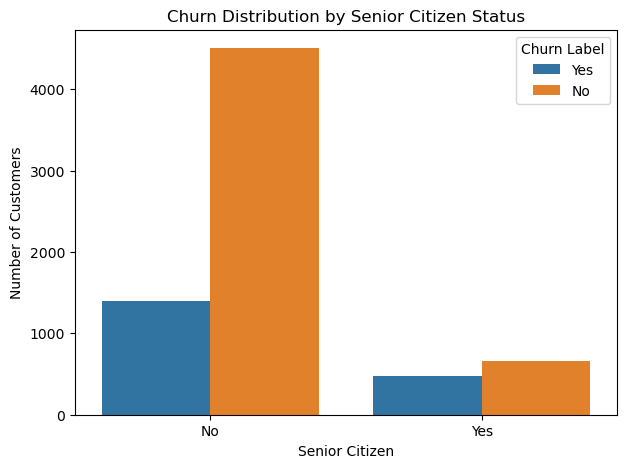

In [62]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="Senior Citizen",
    hue="Churn Label"
)

plt.title("Churn Distribution by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.show()

In [63]:
pd.crosstab(
    eda_df["Partner"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


### Partner Status vs Churn

This analysis compares churn between customers with and without a partner. We use it to check whether customer relationship status is associated with different churn patterns and retention behaviour.

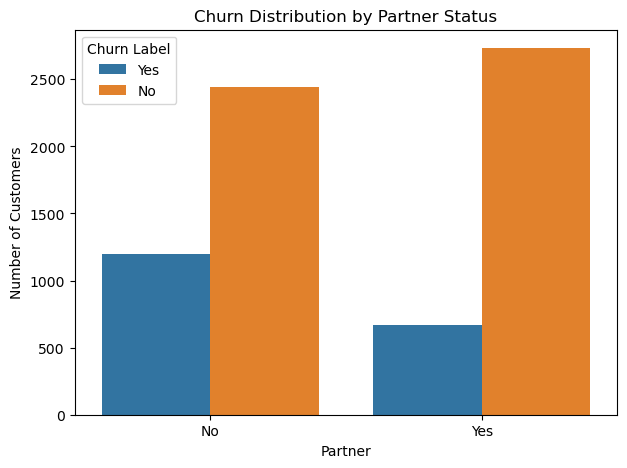

In [64]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="Partner",
    hue="Churn Label"
)

plt.title("Churn Distribution by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.show()

In [65]:
pd.crosstab(
    eda_df["Dependents"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Dependents,,
No,67.448301,32.551699
Yes,93.484942,6.515058


### Dependents vs Churn

This analysis compares churn between customers with and without dependents. We use it to check whether having dependents is associated with different churn patterns and customer retention behaviour.

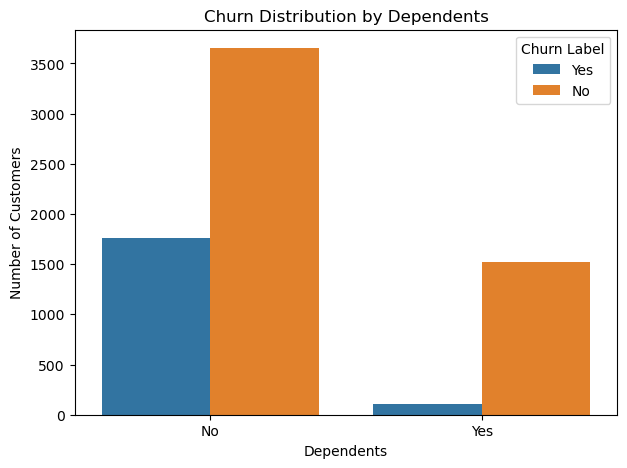

In [66]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="Dependents",
    hue="Churn Label"
)

plt.title("Churn Distribution by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.show()

In [67]:
pd.crosstab(
    eda_df["Gender"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


### Gender vs Churn

This analysis compares churn between different gender groups. We use it to check whether gender is associated with any noticeable difference in churn behaviour.

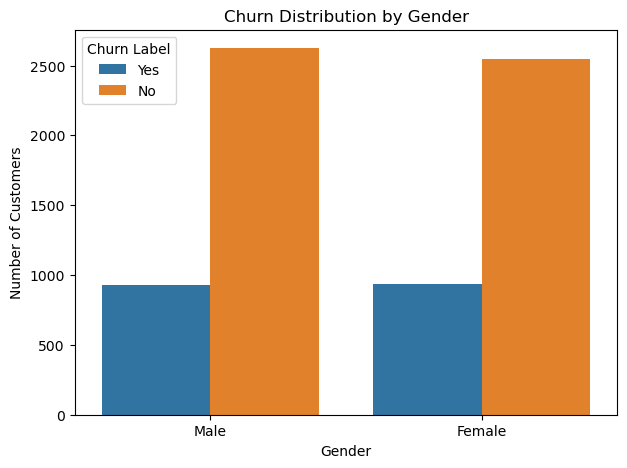

In [68]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="Gender",
    hue="Churn Label"
)

plt.title("Churn Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

## Key EDA Insights

- Analysed the overall **churn distribution** to understand the target variable and identify any class imbalance.

- Compared **Contract Type with Churn** to identify differences in churn behaviour across different contract types.

- Analysed **Internet Service with Churn** to check whether churn patterns differ across service types.

- Studied **Tenure with Churn** to understand how customer relationship duration is associated with churn.

- Compared **Monthly Charges and Total Charges with Churn** to identify differences in customer spending patterns.

- Analysed **Payment Method with Churn** to identify differences in churn behaviour across payment groups.

- Examined **Tech Support and Online Security with Churn** to understand how additional services are associated with customer retention.

- Analysed **Senior Citizen, Partner, Dependents and Gender with Churn** to identify differences across customer groups.

- Used the engineered features **Total Services** and **Support Services** to investigate whether service usage is associated with churn.

- Created a **correlation heatmap** to identify relationships between numerical variables and potential relationships with churn.

- Identified the major **customer segments and features associated with churn**, which can be useful for the modelling stage.

- These observations represent **associations in the dataset and do not necessarily imply causation**.